# House Price Prediction Using Linear Regression

## Objective

Build a Linear Regression model to predict house sale prices using property-related features.

## Dataset

Kaggle House Prices: Advanced Regression Techniques

## Workflow

1. Import libraries
2. Load dataset
3. Explore data
4. Select features
5. Handle missing values
6. Split data
7. Train Linear Regression model
8. Evaluate using RMSE, MAE, and R²
9. Plot residuals
10. Generate sample predictions
11. Save the trained model

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline

In [2]:
# Path from the notebooks folder to the data folder
DATA_PATH = "../data/train.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Dataset Information:")
df.info()
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(15))
print("Statistical summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
dtype: int64

Statistical summary:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
    "FullBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "GarageArea"
]

target = "SalePrice"

X = df[features]
y = df[target]

print("Features used:")
print(features)

print("\nTarget:", target)

Features used:
['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'GarageArea']

Target: SalePrice


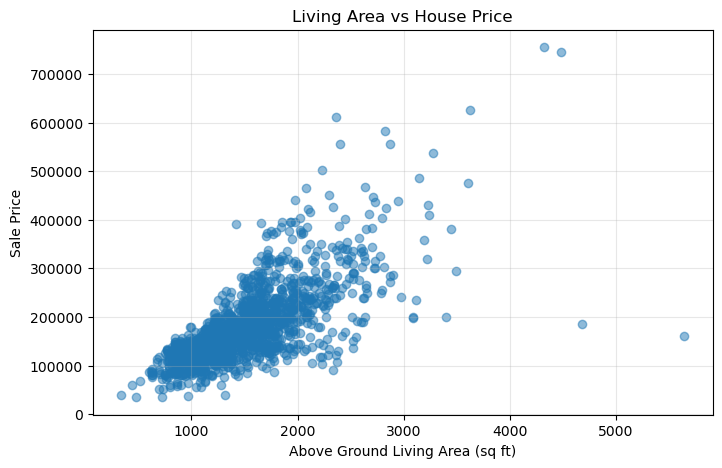

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"],
    alpha=0.5
)

plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.title("Living Area vs House Price")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1168
Testing samples: 292


In [7]:
model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ]
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

display(prediction_df.head())

,Actual Price,Predicted Price
0,154500,140604.379327
1,325000,301872.189381
2,115000,122041.730506
3,159000,174963.739531
4,315500,292392.222295


In [9]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("========== MODEL EVALUATION ==========")
print(f"RMSE     : ${rmse:,.2f}")
print(f"MAE      : ${mae:,.2f}")
print(f"R² Score : {r2:.4f}")

========== MODEL EVALUATION ==========
RMSE     : $38,834.50
MAE      : $24,767.43
R² Score : 0.8034


In [10]:
os.makedirs("../outputs", exist_ok=True)

metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2 Score"],
    "Value": [rmse, mae, r2]
})

display(metrics_df)

metrics_df.to_csv(
    "../outputs/evaluation_metrics.csv",
    index=False
)

,Metric,Value
0,RMSE,38834.501457
1,MAE,24767.431868
2,R2 Score,0.803383


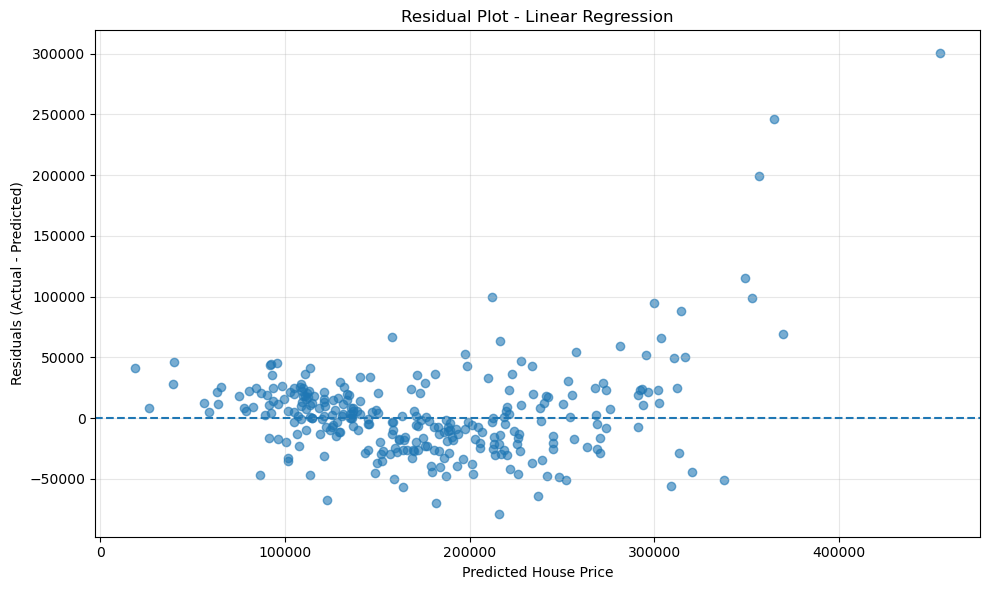

In [11]:
residuals = y_test.values - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Linear Regression")
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs("../plots", exist_ok=True)

plt.savefig(
    "../plots/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

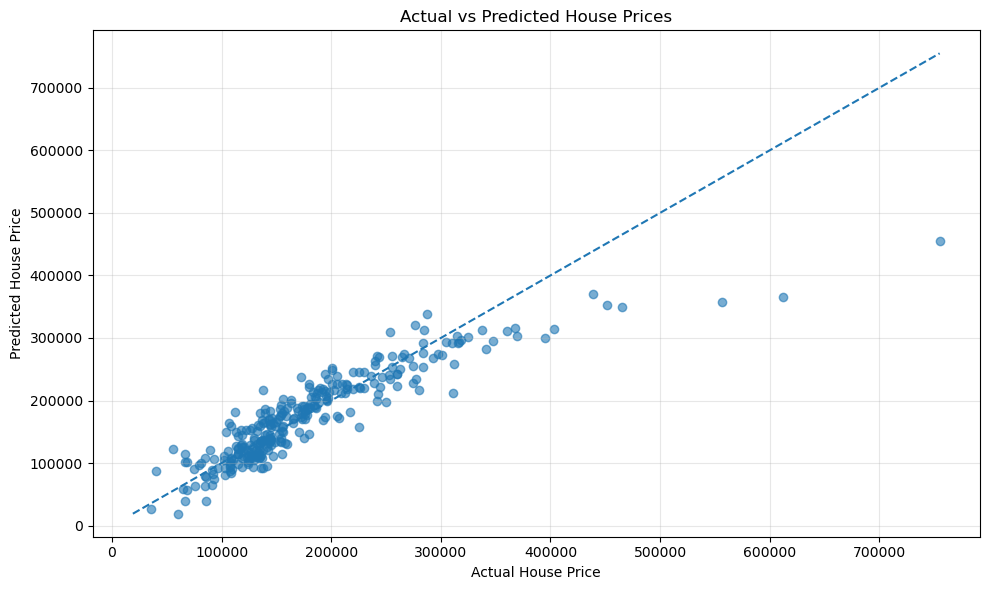

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../plots/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
sample_predictions = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

sample_predictions["Absolute Error"] = (
    sample_predictions["Actual Price"]
    - sample_predictions["Predicted Price"]
).abs()

print("Five sample predictions:")
display(sample_predictions.head(5))

sample_predictions.to_csv(
    "../outputs/sample_predictions.csv",
    index=False
)

Five sample predictions:


,Actual Price,Predicted Price,Absolute Error
0,154500,140604.379327,13895.620673
1,325000,301872.189381,23127.810619
2,115000,122041.730506,7041.730506
3,159000,174963.739531,15963.739531
4,315500,292392.222295,23107.777705


In [14]:
os.makedirs("../models", exist_ok=True)

model_path = "../models/linear_regression_house_price.pkl"

joblib.dump(model, model_path)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: ../models/linear_regression_house_price.pkl


In [15]:
loaded_model = joblib.load(
    "../models/linear_regression_house_price.pkl"
)

# Use one test sample
sample_house = X_test.iloc[[0]]

loaded_prediction = loaded_model.predict(sample_house)

print(f"Predicted price: ${loaded_prediction[0]:,.2f}")
print(f"Actual price:    ${y_test.iloc[0]:,.2f}")

Predicted price: $140,604.38
Actual price:    $154,500.00
